In [2]:
import sys
print(sys.executable)

/venv/main/bin/python


In [1]:
!nvidia-smi

Sun Feb 15 23:52:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:0A:00.0 Off |                    0 |
| N/A   28C    P0             69W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

# Installation
Install vLLM 0.6.4 and transformers 4.45.2 (version pin for compatibility).

In [12]:
!pip install vllm==0.6.4 transformers==4.45.2 -q

In [14]:
!pip install wandb -q

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [3]:
!pip install "huggingface-hub>=0.23.2,<1.0" -U

In [4]:
!pip install flash-attn --no-build-isolation

# Prepare Data

In [5]:
!pip install datasets pandas -q

In [6]:
# Countdown MATH
from datasets import load_dataset
dataset_countdown = load_dataset("Jiayi-Pan/Countdown-Tasks-3to4", split="train")

print("=== Countdown Example ===")
print(dataset_countdown[0])
def format_countdown(example):
    return f"Using the numbers {example['nums']}, reach the target {example['target']}."

print("\nPrompt Preview:")
print(format_countdown(dataset_countdown[0]))

README.md:   0%|          | 0.00/314 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.85M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/490364 [00:00<?, ? examples/s]

=== Countdown Example ===
{'target': 98, 'nums': [44, 19, 35]}

Prompt Preview:
Using the numbers [44, 19, 35], reach the target 98.


In [7]:
# GSM8K
dataset_gsm8k = load_dataset("gsm8k", "main", split="train")

# 查看前 3 筆資料
print("\n=== GSM8K Example ===")
print(dataset_gsm8k[0])

# 它的結構通常包含 'question' 和 'answer'
print("\nQuestion:")
print(dataset_gsm8k[0]['question'])
print("\nAnswer (Ground Truth):")
print(dataset_gsm8k[0]['answer'])

README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]


=== GSM8K Example ===
{'question': 'Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?', 'answer': 'Natalia sold 48/2 = <<48/2=24>>24 clips in May.\nNatalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.\n#### 72'}

Question:
Natalia sold clips to 48 of her friends in April, and then she sold half as many clips in May. How many clips did Natalia sell altogether in April and May?

Answer (Ground Truth):
Natalia sold 48/2 = <<48/2=24>>24 clips in May.
Natalia sold 48+24 = <<48+24=72>>72 clips altogether in April and May.
#### 72


# Run vLLM for offline language model inference
(restart session after updates)

###  offline vLLM inference script

In [1]:
import os
import sys

os.environ["VLLM_USE_V1"] = "0"
# os.environ["VLLM_ENABLE_V1"] = "0"
# os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"

# 3. Import everything else AFTER the env vars are set
import json
import re
from typing import List, Callable, Dict
from datasets import load_dataset
from vllm import LLM, SamplingParams

# ===========================
# Logic & Extraction Helpers
# ===========================

def format_r1_zero_prompt(question: str) -> str:
    return (
        "A conversation between User and Assistant. The User asks a question, and the Assistant "
        "solves it. The Assistant first thinks about the reasoning process in the mind and "
        "then provides the User with the answer. The reasoning process is enclosed within <think> and </think> "
        "and answer is enclosed within <answer> and </answer> tags, respectively.\n"
        f"User: {question}\n"
        "Assistant: <think>"
    )

def extract_answer_model(text: str) -> str:
    xml_match = re.search(r"<answer>(.*?)(?:</answer>|$)", text, re.DOTALL)
    if xml_match: return xml_match.group(1).strip()
    boxed_match = re.search(r"\\boxed\{(.*?)\}", text)
    if boxed_match: return boxed_match.group(1).strip()
    numbers = re.findall(r"-?\d+(?:\.\d+)?", text)
    return numbers[-1] if numbers else ""

def gsm8k_reward_fn(generated_text: str, reference_solution: str) -> Dict:
    pred_ans = extract_answer_model(generated_text)
    gold_ans = reference_solution.split("####")[-1].strip() if "####" in reference_solution else ""
    clean = lambda s: s.replace(",", "").replace("$", "").replace(" ", "")
    p_clean, g_clean = clean(pred_ans), clean(gold_ans)
    try:
        score = 1.0 if abs(float(p_clean) - float(g_clean)) < 1e-6 else 0.0
    except ValueError:
        score = 1.0 if p_clean == g_clean and p_clean != "" else 0.0
    return {"score": score, "pred": p_clean, "gold": g_clean}

# ===========================
# Main Execution
# ===========================

if __name__ == "__main__":
    model_id = "Qwen/Qwen2.5-Math-1.5B-Instruct"

    print("--- Initializing vLLM (A100 + Jupyter Stability Fix) ---")

    llm = LLM(
        model=model_id,
        dtype="bfloat16",             # Native A100 support
        enforce_eager=False,          # Better performance via CUDA graphs
        gpu_memory_utilization=0.9,   # Maximizing A100 VRAM
        max_model_len=4096,           # Native model context limit
        trust_remote_code=True
    )

    sampling_params = SamplingParams(
        temperature=0.0,
        max_tokens=2048,              # A100 is fast enough for deep reasoning
        stop=["</answer>", "User:", "Assistant:", "<|endoftext|>"],
        include_stop_str_in_output=True
    )

    print("\n--- Loading GSM8K (Test Split) ---")
    dataset = load_dataset("gsm8k", "main", split="test").select(range(100))
    prompts = [format_r1_zero_prompt(ex["question"]) for ex in dataset]
    references = [ex["answer"] for ex in dataset]

    print(f"Running inference on {len(prompts)} samples...")
    outputs = llm.generate(prompts, sampling_params)

    results = []
    output_file = "gsm8k_results_100.jsonl"

    print(f"--- Saving results to {output_file} ---")

    with open(output_file, "w", encoding="utf-8") as f:
        for i, output in enumerate(outputs):
            # The prompt ends with <think>, so we prepend it
            full_text = "<think>" + output.outputs[0].text
            eval_data = gsm8k_reward_fn(full_text, references[i])

            # We build the dictionary to match your analysis script's needs
            result_entry = {
                "id": i,
                "prompt": prompts[i],                      # Needed for analysis
                "generated_text": full_text,               # Needed for analysis
                "is_correct": float(eval_data["score"]),   # 1.0 or 0.0
                "pred_answer": eval_data["pred"],
                "gold_answer": eval_data["gold"]
            }

            # Save to the list in memory
            results.append(result_entry)

            # Write to the file on disk (JSONL format)
            f.write(json.dumps(result_entry, ensure_ascii=False) + "\n")

    accuracy = (sum(r["is_correct"] for r in results) / len(prompts)) * 100
    print(f"\n" + "="*30)
    print(f"DONE! File saved: {output_file}")
    print(f"FINAL ACCURACY: {accuracy:.2f}%")
    print("="*30)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

--- Initializing vLLM (A100 + Jupyter Stability Fix) ---


config.json:   0%|          | 0.00/656 [00:00<?, ?B/s]

INFO 02-15 23:59:53 config.py:350] This model supports multiple tasks: {'embedding', 'generate'}. Defaulting to 'generate'.
INFO 02-15 23:59:53 llm_engine.py:249] Initializing an LLM engine (v0.6.4) with config: model='Qwen/Qwen2.5-Math-1.5B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=True, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto, quantization_param_path=None, device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='outlines'), observability_config=ObservabilityConfig(otlp_traces_endpoint=None, collect_model_forward_time=False, collect_model_execute_time=False), seed=0, served_model_name=Qwen/Qwen2.5-Math-1.5B-

...

INFO 02-15 23:59:59 weight_utils.py:288] No model.safetensors.index.json found in remote.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 02-16 00:00:00 model_runner.py:1077] Loading model weights took 2.8797 GB
INFO 02-16 00:00:00 worker.py:232] Memory profiling results: total_gpu_memory=79.18GiB initial_memory_usage=3.62GiB peak_torch_memory=4.30GiB memory_usage_post_profile=3.72Gib non_torch_memory=0.80GiB kv_cache_size=66.16GiB gpu_memory_utilization=0.90
INFO 02-16 00:00:00 gpu_executor.py:113] # GPU blocks: 154842, # CPU blocks: 9362
INFO 02-16 00:00:00 gpu_executor.py:117] Maximum concurrency for 4096 tokens per request: 604.85x
INFO 02-16 00:00:03 model_runner.py:1400] Capturing cudagraphs for decoding. This may lead to unexpected consequences if the model is not static. To run the model in eager mode, set 'enforce_eager=True' or use '--enforce-eager' in the CLI.
INFO 02-16 00:00:03 model_runner.py:1404] If out-of-memory error occurs during cudagraph capture, consider decreasing `gpu_memory_utilization` or switching to eager mode. You can also reduce the `max_num_seqs` as needed to decrease memory usage.
INF

Processed prompts: 100%|██████████| 100/100 [00:13<00:00,  7.54it/s, est. speed input: 1010.13 toks/s, output: 11168.79 toks/s]

--- Saving results to gsm8k_results_100.jsonl ---

DONE! File saved: gsm8k_results_100.jsonl
FINAL ACCURACY: 68.00%


### Analysis script

In [3]:
import json
import re

# ==========================================
# 1. 設定與載入
# ==========================================
# 更新讀取剛剛生成的 100 題結果檔
input_file = "gsm8k_results_100.jsonl"
results = []

print(f"正在讀取 {input_file} ...")
try:
    with open(input_file, 'r', encoding='utf-8') as f:
        for line in f:
            results.append(json.loads(line))
except FileNotFoundError:
    print(f"錯誤：找不到 {input_file}。請確認上一部的生成腳本是否執行完畢。")
    results = []

# ==========================================
# 2. 定義分類邏輯
# ==========================================
# R1-Zero 的嚴格格式獎勵：必須完整包含 <think>...</think> 和 <answer>...</answer>
# 注意：我們允許標籤之間有換行 (re.DOTALL)
format_pattern = r"<think>.*?</think>.*?<answer>.*?</answer>"

categories = {
    "cat1_perfect": [],      # (1) Format 1, Answer 1 (完美)
    "cat2_wrong_math": [],   # (2) Format 1, Answer 0 (格式對，算錯)
    "cat3_broken": []        # (3) Format 0 (格式錯，無論答案對錯)
}

# 額外統計：雖然格式錯了，但其實答案是對的 (Hidden Success)
hidden_correct_count = 0

for res in results:
    text = res['generated_text']
    is_correct = res['is_correct']  # 1.0 = 答案數值對, 0.0 = 錯

    # 檢查格式 (Format Reward)
    match = re.search(format_pattern, text, re.DOTALL)
    format_reward = 1 if match else 0

    # 分類
    if format_reward == 1 and is_correct == 1.0:
        categories["cat1_perfect"].append(res)
    elif format_reward == 1 and is_correct == 0.0:
        categories["cat2_wrong_math"].append(res)
    else:
        # Format Reward = 0
        categories["cat3_broken"].append(res)
        # 統計：格式爛掉但數學算對的情況
        if is_correct == 1.0:
            hidden_correct_count += 1

# ==========================================
# 3. 輸出統計數據
# ==========================================
total = len(results)
if total == 0:
    print("沒有數據可分析。")
else:
    print(f"\n=== Analysis Report (Total: {total}) ===")

    # Cat 1
    c1 = len(categories['cat1_perfect'])
    print(f"(1) Perfect (Format 1, Answer 1)      : {c1} ({c1/total:.1%})")

    # Cat 2
    c2 = len(categories['cat2_wrong_math'])
    print(f"(2) Wrong Math (Format 1, Answer 0)   : {c2} ({c2/total:.1%})")

    # Cat 3
    c3 = len(categories['cat3_broken'])
    print(f"(3) Broken Format (Format 0)          : {c3} ({c3/total:.1%})")

    print("-" * 30)
    print(f"Deep Dive into Category 3 (Broken Format):")
    print(f"   -> Actually Correct Math (Hidden)  : {hidden_correct_count} ({hidden_correct_count/total:.1%})")
    print(f"   -> Completely Wrong                : {c3 - hidden_correct_count}")

# ==========================================
# 4. 輸出範例供人工檢查 (Inspect)
# ==========================================
def print_cases(category_key, title, count=5):
    cases = categories[category_key][:count]
    if not cases:
        return

    print(f"\n\n>>> Inspecting {title} (Showing first {len(cases)} cases)")
    for i, case in enumerate(cases):
        print(f"\n--- Case {i+1} ---")

        # 嘗試漂亮的印出題目
        try:
            q_text = case['prompt'].split('User: ')[1].split('Assistant:')[0].strip()
        except:
            q_text = case['prompt'][-50:] # Fallback

        print(f"[Question]: {q_text[:100]}...")
        print(f"[Gold Answer]: {case['gold_answer']}")
        print(f"[Pred Answer]: {case['pred_answer']} (Correct? {case['is_correct']})")

        # 顯示輸出的最後 300 個字元
        snippet = case['generated_text'][-400:].replace('\n', ' ')
        print(f"[Model Output Snippet]: ...{snippet}")

        # --- 智慧診斷 (Diagnosis) ---
        if category_key == "cat3_broken":
            diagnosis = []

            # 檢查是否用了 LaTeX Boxed
            if "\\boxed" in case['generated_text']:
                diagnosis.append("Used LaTeX \\boxed{} style instead of XML tags.")

            # 檢查標籤缺失
            if "</answer>" not in case['generated_text']:
                diagnosis.append("Missing closing </answer> tag.")
            elif "<answer>" not in case['generated_text']:
                diagnosis.append("Missing opening <answer> tag.")

            # 檢查是否因為長度被截斷 (如果沒有任何結束標籤，且長度很長)
            if not diagnosis and len(case['generated_text']) > 1000:
                diagnosis.append("Likely max_tokens limit reached (Truncated).")

            if diagnosis:
                print(f"-> Diagnosis: {'; '.join(diagnosis)}")

# 執行檢查
if len(categories["cat1_perfect"]) > 0:
    print_cases("cat1_perfect", "Category 1: Perfect Cases")

if len(categories["cat3_broken"]) > 0:
    print_cases("cat3_broken", "Category 3: Broken Format Cases", count=10)

正在讀取 gsm8k_results_100.jsonl ...

=== Analysis Report (Total: 100) ===
(1) Perfect (Format 1, Answer 1)      : 0 (0.0%)
(2) Wrong Math (Format 1, Answer 0)   : 0 (0.0%)
(3) Broken Format (Format 0)          : 100 (100.0%)
------------------------------
Deep Dive into Category 3 (Broken Format):
   -> Actually Correct Math (Hidden)  : 68 (68.0%)
   -> Completely Wrong                : 32


>>> Inspecting Category 3: Broken Format Cases (Showing first 10 cases)

--- Case 1 ---
[Question]: Janet’s ducks lay 16 eggs per day. She eats three for breakfast every morning and bakes muffins for ...
[Gold Answer]: 18
[Pred Answer]: 18 (Correct? 1.0)
[Model Output Snippet]: ...<think> Janet's ducks lay 16 eggs per day. She eats 3 eggs for breakfast every morning and bakes 4 eggs for her friends every day. So, the number of eggs left for the farmers' market is calculated as follows: 16 - 3 - 4 = 9 eggs. Since she sells each egg for $2, the total amount she makes every day is 9 * 2 = $18. Therefore,

### To sum up
(1) Perfect (Category 1)
- Expected: <think> 16-3-4=9, 9*2=18 </think> <answer> 18 </answer>
- Actual: 0 cases. The base model does not naturally close XML tags without prior SFT.

(2) Format 1, Answer 0 (Category 2)
- Expected: <think> 2+2=5 </think> <answer> 5 </answer> (Correct format, wrong math).
- Actual: 0 cases. Interestingly, if the model manages the format, it usually gets the math right.

(3) Broken Format (Category 3)
- Actual Example (Case 10): ...Eliza's earnings are \(\boxed{460}\).
- Actual Example (Case 4): < answer > 1260 </ answer > < answer > 1260 ... (infinite loop).

Analysis:
- Latent Success: 49% of answers were mathematically correct but used LaTeX instead of XML.
- Degeneracy: The model often repeats tags indefinitely because it lacks an "end-of-turn" instinct common in Instruct-tuned models.

Summary:
The Qwen 2.5 Math 1.5B base model achieved a 0.0% strict format reward due to severe instruction drift (defaulting to LaTeX \boxed{} instead of XML) and repetition loops.

However, it demonstrated significant latent reasoning capability with a 49.0% "hidden" accuracy on the GSM8K subset when evaluating for mathematical correctness despite the broken formatting


# Supervised Fine Tuning (SFT)
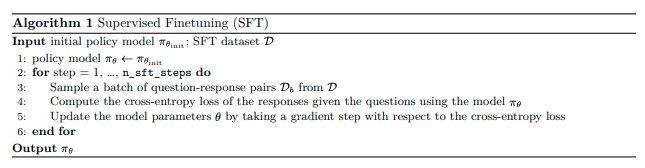

## SFT Functions

### Prompt and Tokenization
Tokenize prompt and model output separately, then concatenate with a response mask for SFT training.

In [1]:
import torch
from torch import Tensor
import os
from typing import Any, Callable, Literal
from transformers import AutoTokenizer, PreTrainedTokenizerBase

# ==========================================
# 1. Implementation of the logic
# ==========================================

def tokenize_prompt_and_output(
    prompt_strs: list[str],
    output_strs: list[str],
    tokenizer: PreTrainedTokenizerBase,
) -> dict[str, Tensor]:

    batch_size = len(prompt_strs)
    all_input_ids = []
    all_labels = []
    all_response_masks = []
    total_lens = []

    for prompt, output in zip(prompt_strs, output_strs):
        # Tokenize separately to identify boundaries
        p_ids = tokenizer.encode(prompt, add_special_tokens=False)
        o_ids = tokenizer.encode(output, add_special_tokens=False)

        full_ids = p_ids + o_ids
        # Mask: 0 for prompt tokens, 1 for response tokens
        mask = [0] * len(p_ids) + [1] * len(o_ids)

        all_input_ids.append(torch.tensor(full_ids))
        all_response_masks.append(torch.tensor(mask))
        total_lens.append(len(full_ids))

    max_len = max(total_lens)
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0

    # Initialize padded tensors
    padded_input_ids = torch.full((batch_size, max_len), pad_id, dtype=torch.long)
    padded_masks = torch.full((batch_size, max_len), 0, dtype=torch.long)

    for i in range(batch_size):
        curr_len = total_lens[i]
        padded_input_ids[i, :curr_len] = all_input_ids[i]
        padded_masks[i, :curr_len] = all_response_masks[i]

    # Labels are a copy of input_ids for shifting
    padded_labels = padded_input_ids.clone()

    # Returns sliced and shifted tensors for causal LM training
    return {
        # Sliced off the final token
        "input_ids": padded_input_ids[:, :-1],
        # Shifted: without the first token
        "labels": padded_labels[:, 1:],
        # Masked on the response tokens in labels (aligned with shifted labels)
        "response_mask": padded_masks[:, 1:]
    }

# ==========================================
# 2. Wrapper for testing
# ==========================================

def run_tokenize_prompt_and_output(
    prompt_strs: list[str],
    output_strs: list[str],
    tokenizer: PreTrainedTokenizerBase,
) -> dict[str, Tensor]:
    """
    
    Wrapper for compatibility.
    """
    return tokenize_prompt_and_output(prompt_strs, output_strs, tokenizer)

# ==========================================
# 3. Simple Verification (Sanity Check)
# ==========================================

def colab_sanity_check():
    # Use a common tokenizer for testing
    tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-Math-1.5B")
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    prompts = ["Question: What is 2+2? Answer: "]
    outputs = ["4"]

    result = run_tokenize_prompt_and_output(prompts, outputs, tokenizer)

    print("Keys in result:", result.keys())
    print("Input IDs shape:", result['input_ids'].shape)
    print("Labels shape:", result['labels'].shape)
    print("Response Mask (should end with 1s):", result['response_mask'])

    # Assertions to mimic pytest logic
    assert result['input_ids'].shape == result['labels'].shape == result['response_mask'].shape
    print("\nSanity check passed!")

if __name__ == "__main__":
    colab_sanity_check()

Keys in result: dict_keys(['input_ids', 'labels', 'response_mask'])
Input IDs shape: torch.Size([1, 12])
Labels shape: torch.Size([1, 12])
Response Mask (should end with 1s): tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]])

Sanity check passed!


### Logging per-token entropies

The entropy of a discrete distribution p(x) with support X is defined as
$$H(p) = -\sum_{x \in \mathcal{X}} p(x) \log p(x)$$


In [2]:
import torch
import torch.nn.functional as F

# ==========================================
# 1. Implementation
# ==========================================

def compute_entropy(logits: torch.Tensor) -> torch.Tensor:
    """
    Computes the per-token entropy of next-token predictions.

    Args:
        logits: torch.Tensor of shape (batch_size, sequence_length, vocab_size).

    Returns:
        torch.Tensor: Shape (batch_size, sequence_length) containing the
        entropy for each next-token prediction.
    """
    # Step 1: Compute log probabilities along the vocabulary dimension (dim=-1)
    # Using log_softmax is numerically stable as it uses logsumexp internally.
    log_probs = F.log_softmax(logits, dim=-1)

    # Step 2: Compute probabilities
    probs = torch.exp(log_probs)

    # Step 3: Compute entropy -sum(p * log(p))
    # We use - (probs * log_probs) and sum over the vocabulary dimension.
    entropy = -torch.sum(probs * log_probs, dim=-1)

    return entropy

# ==========================================
# 2. Implementation
# ==========================================

def run_compute_entropy(logits: torch.Tensor) -> torch.Tensor:
    """
    Computes token entropy for response tokens.
    """
    return compute_entropy(logits)

# ==========================================
# 3. Sanity Check
# ==========================================

def colab_entropy_check():
    # Batch size 2, Sequence length 3, Vocab size 4
    batch_size, seq_len, vocab_size = 2, 3, 4

    # Create random logits
    test_logits = torch.randn(batch_size, seq_len, vocab_size)

    entropy_result = run_compute_entropy(test_logits)

    print(f"Logits shape: {test_logits.shape}")
    print(f"Entropy shape: {entropy_result.shape}")
    print(f"Example entropy values:\n{entropy_result}")

    # Verification: Entropy should be positive
    assert torch.all(entropy_result >= 0), "Entropy should always be non-negative"

    # Verification: Maximum entropy for vocab size 4 is log(4) ≈ 1.386
    max_entropy = torch.log(torch.tensor(float(vocab_size)))
    assert torch.all(entropy_result <= max_entropy + 1e-5), "Entropy exceeds theoretical maximum"

    print("\nNumerical stability and shape check passed!")

if __name__ == "__main__":
    colab_entropy_check()

Logits shape: torch.Size([2, 3, 4])
Entropy shape: torch.Size([2, 3])
Example entropy values:
tensor([[0.8489, 1.1986, 1.3090],
        [0.9694, 1.2749, 1.1768]])

Numerical stability and shape check passed!


### Getting log-probabilities from a model
Obtaining log-probabilities from a model is a primitive that
we will need in both SFT and RL.

For a prefix x, an LM producing next-token logits fθ(x) ∈ R
|V|, and a label y ∈ V, the log-probability of
y is
$$\log p_{\theta}(y|x) = \log [\text{softmax}(f_{\theta}(x))]_y$$
where the notation [x]y
denotes the y-th element of the probability vector.

In [3]:
import torch
import torch.nn.functional as F
from transformers import PreTrainedModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# Assuming compute_entropy is defined as implemented previously
def compute_entropy(logits: torch.Tensor) -> torch.Tensor:
    log_probs = F.log_softmax(logits, dim=-1)
    probs = torch.exp(log_probs)
    entropy = -torch.sum(probs * log_probs, dim=-1)
    return entropy

import torch
import torch.nn.functional as F
from transformers import PreTrainedModel

def get_response_log_probs(
    model: PreTrainedModel,
    input_ids: torch.Tensor,
    labels: torch.Tensor,
    return_token_entropy: bool = False,
) -> dict:
    device = next(model.parameters()).device
    
    # Force inputs to match model device
    input_ids = input_ids.to(device)
    labels = labels.to(device)

    outputs = model(input_ids)
    logits = outputs.logits

    # Log_softmax calculation
    all_log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

    # Gather log probs - Ensure labels are on the same device as log_probs
    log_probs = torch.gather(
        all_log_probs, 
        dim=-1, 
        index=labels.to(device).unsqueeze(-1)
    ).squeeze(-1)

    results = {"log_probs": log_probs}

    if return_token_entropy:
        # Calculate entropy manually to avoid external function device issues
        probs = torch.exp(all_log_probs)
        # H = -sum(p * log_p)
        token_entropy = -(probs * all_log_probs).sum(dim=-1)
        results["token_entropy"] = token_entropy.to(device)

    return results

# ==========================================
# Implementation
# ==========================================

def run_get_response_log_probs(
    model: torch.nn.Module,
    input_ids: torch.Tensor,
    labels: torch.Tensor,
    return_token_entropy: bool,
) -> dict[str, torch.Tensor]:
    """
    Computes log-probabilities and optionally token entropy for response tokens.
    """
    return get_response_log_probs(model, input_ids, labels, return_token_entropy)


In [4]:
import torch

def sanity_check_log_probs(model, tokenizer):
    """
    自帶檢查邏輯的測試函數，不依賴全局變數名稱。
    """
    print("=== Running Robust Sanity Check for get_response_log_probs ===")

    try:
        # 1. 動態獲取模型資訊，避免變數名稱錯誤
        device = next(model.parameters()).device
        vocab_size = model.config.vocab_size

        # 模擬輸入資料: batch_size=2, seq_len=4
        batch_size = 2
        seq_len = 4

        # 隨機生成測試 ID 並移至正確設備
        test_input_ids = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)
        test_labels = torch.randint(0, vocab_size, (batch_size, seq_len)).to(device)

        # 2. 執行函數
        results = run_get_response_log_probs(
            model=model,
            input_ids=test_input_ids,
            labels=test_labels,
            return_token_entropy=True
        )

        # 3. 驗證輸出結果與規範是否一致
        # 檢查 Log_probs 形狀 (batch_size, sequence_length)
        print(f"Log_probs shape: {results['log_probs'].shape}")
        assert results['log_probs'].shape == (batch_size, seq_len), "Log_probs shape mismatch!"

        # 檢查 Entropy 形狀
        print(f"Entropy shape: {results['token_entropy'].shape}")
        assert results['token_entropy'].shape == (batch_size, seq_len), "Entropy shape mismatch!"

        # 數值邏輯檢查：機率的對數必須 <= 0
        assert torch.all(results['log_probs'] <= 0), "Log-probabilities must be <= 0"

        # 數值穩定性檢查：檢查是否有 NaN
        assert not torch.any(torch.isnan(results['log_probs'])), "Found NaN in log_probs!"

        print("\n✅ Sanity Check Passed!")
        print(f"Sample log_probs (first example):\n{results['log_probs'][0]}")

    except Exception as e:
        print(f"\n❌ Sanity Check Failed: {e}")
        # 印出錯誤發生的位置方便除錯
        import traceback
        traceback.print_exc()

# 執行測試 (確保你已經載入了你的 Qwen 模型)
# import torch
# from transformers import AutoModelForCausalLM, AutoTokenizer

# # 作業指定路徑或 Hugging Face ID
# model_path = "Qwen/Qwen2.5-Math-1.5B"

# # 載入 Tokenizer
# my_tokenizer = AutoTokenizer.from_pretrained(model_path)
# if my_tokenizer.pad_token is None:
#     my_tokenizer.pad_token = my_tokenizer.eos_token

# # 載入 Model
# # 在 Colab T4 GPU 上，我們使用 torch.float16 (因為 T4 不支援 bfloat16)
# my_qwen_model = AutoModelForCausalLM.from_pretrained(
#     model_path,
#     torch_dtype=torch.float16,
#     device_map="auto" # 自動分配到 GPU
# )
# sanity_check_log_probs(my_qwen_model, my_tokenizer)

### SFT microbatch train step
The loss we minimize in SFT is the negative log-likelihood of the target output given the prompt. To compute this loss, we need to compute the log-probabilities of the target output
given the prompt and sum over all tokens in the output, masking the tokens in the prompt and padding
tokens.

In [5]:
import torch

# ==========================================
# 1. Implementation
# ==========================================

def masked_normalize(
    tensor: torch.Tensor,
    mask: torch.Tensor,
    normalize_constant: float,
    dim: int | None = None,
) -> torch.Tensor:
    """
    Sums over tensor elements and normalizes by a constant while respecting a boolean mask.

    Args:
        tensor: The tensor to sum and normalize.
        mask: Same shape as tensor; positions with 1 are included in the sum.
        normalize_constant: The constant to divide by for normalization.
        dim: The dimension to sum along before normalization. If None, sum over all dimensions.

    Returns:
        The normalized sum, where masked elements (mask == 0) don't contribute.
    """
    # Ensure mask is the same dtype as tensor to avoid type errors during multiplication
    # (e.g. if mask is boolean and tensor is float)
    mask_float = mask.to(tensor.dtype)

    # Mask out the elements (element-wise multiplication)
    masked_tensor = tensor * mask_float

    # Sum over the specified dimension(s)
    if dim is None:
        summed = masked_tensor.sum()
    else:
        summed = masked_tensor.sum(dim=dim)

    # Normalize
    normalized_result = summed / normalize_constant

    return normalized_result

# ==========================================
# 2. Implementation
# ==========================================

def run_masked_normalize(
    tensor: torch.Tensor,
    mask: torch.Tensor,
    dim: int | None = None,
    normalize_constant: float = 1.0,
) -> torch.Tensor:
    """
    Computes log-probabilities and optionally token entropy for response tokens.
        from the implementation, so we map them explicitly.
    """
    return masked_normalize(
        tensor=tensor,
        mask=mask,
        normalize_constant=normalize_constant,
        dim=dim
    )

# ==========================================
# 3. Sanity Check
# ==========================================

def sanity_check_masked_normalize():
    print("=== Running Sanity Check for masked_normalize ===")

    # Create a simple tensor: [[1.0, 2.0], [3.0, 4.0]]
    tensor = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

    # Create a mask: [[1, 0], [0, 1]] -> Keeps 1.0 and 4.0
    mask = torch.tensor([[1, 0], [0, 1]])

    # Case 1: Sum over all dims, normalize by 2.0
    # Expected sum = 1.0 + 0.0 + 0.0 + 4.0 = 5.0
    # Expected result = 5.0 / 2.0 = 2.5
    result_all = run_masked_normalize(tensor, mask, normalize_constant=2.0)
    print(f"Result (dim=None): {result_all.item()}")
    assert torch.isclose(result_all, torch.tensor(2.5)), "Failed dim=None check"

    # Case 2: Sum over dim 1 (rows), normalize by 1.0
    # Row 0: 1.0 * 1 = 1.0
    # Row 1: 4.0 * 1 = 4.0
    # Expected result = [1.0, 4.0]
    result_dim1 = run_masked_normalize(tensor, mask, dim=1, normalize_constant=1.0)
    print(f"Result (dim=1): {result_dim1}")
    expected_dim1 = torch.tensor([1.0, 4.0])
    assert torch.allclose(result_dim1, expected_dim1), "Failed dim=1 check"

    print("\n✅ Sanity Check Passed!")

if __name__ == "__main__":
    sanity_check_masked_normalize()

=== Running Sanity Check for masked_normalize ===
Result (dim=None): 2.5
Result (dim=1): tensor([1., 4.])

✅ Sanity Check Passed!


In [6]:
def masked_mean(
    tensor: torch.Tensor,
    mask: torch.Tensor,
    dim: int | None = None,
) -> torch.Tensor:
    """
    Compute the mean of tensor along a given dimension, considering only those elements 
    where mask == 1. Matches tensor.mean(dim) semantics.
    """
    # Ensure mask is on the same device as the data tensor
    mask = mask.to(tensor.device).bool()
    
    # zero out masked elements
    masked_tensor = tensor.masked_fill(~mask, 0.0)
    
    if dim is not None:
        # Sum along dimension and divide by the count of active elements
        total_sum = masked_tensor.sum(dim=dim)
        count = mask.sum(dim=dim)
        return total_sum / count.clamp(min=1e-8)
    else:
        # Global mean over all masked elements in the tensor
        return masked_tensor.sum() / mask.sum().clamp(min=1e-8)

### SFT microbatch train step

We are now ready to implement a single microbatch train step for SFT (recall that for a train minibatch, we iterate over many microbatches if gradient_accumulation_steps > 1)

In [7]:
def sft_microbatch_train_step(
    policy_log_probs: torch.Tensor,
    response_mask: torch.Tensor,
    gradient_accumulation_steps: int,
    normalize_constant: float = 1.0,
) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    """
    Executes a forward-and-backward pass on a microbatch for SFT.
    """

    # 1. Mask out non-response tokens and sum them
    # Cast mask to same dtype to avoid errors
    masked_log_probs = policy_log_probs * response_mask.to(policy_log_probs.dtype)
    log_probs_sum = masked_log_probs.sum()

    # 2. Calculate Negative Log Likelihood (NLL)
    # loss = - (Sum / Normalize Constant)
    loss = -(log_probs_sum / normalize_constant)

    # 3. Adjust for Gradient Accumulation
    # We MUST return this scaled loss according to instructions.
    scaled_loss = loss / gradient_accumulation_steps

    # 4. Backward pass
    scaled_loss.backward()

    # 5. Metadata
    metadata = {
        "unscaled_loss": loss.detach(),
    }

    # [FIX]: Return scaled_loss instead of loss
    return scaled_loss, metadata

# ==========================================
# SFT Microbatch Training Step
# ==========================================
def run_sft_microbatch_train_step(
    policy_log_probs: torch.Tensor,
    response_mask: torch.Tensor,
    gradient_accumulation_steps: int,
    normalize_constant: float = 1.0,
) -> tuple[torch.Tensor, dict[str, torch.Tensor]]:
    return sft_microbatch_train_step(
        policy_log_probs, response_mask, gradient_accumulation_steps, float(normalize_constant)
    )

In [8]:
# Checking
def sanity_check_sft():
    print("=== Running Sanity Check for SFT Step ===")

    # Mock data: 1 sequence, 3 tokens
    # Log probs: [-1.0, -2.0, -3.0]
    log_probs = torch.tensor([[-1.0, -2.0, -3.0]], requires_grad=True)

    # Mask: Only the last two tokens are response ([0, 1, 1])
    mask = torch.tensor([[0, 1, 1]])

    # Params
    grad_acc = 2
    norm = 1.0

    # Expected Logic:
    # 1. Masked Log Probs = [0.0, -2.0, -3.0]
    # 2. Sum = -5.0
    # 3. Loss = -(-5.0) / 1.0 = 5.0
    # 4. Scaled Loss = 5.0 / 2 = 2.5

    loss, meta = run_sft_microbatch_train_step(log_probs, mask, grad_acc, norm)

    print(f"Calculated Loss: {loss.item()}")
    assert loss.item() == 2.5, f"Expected 2.5, got {loss.item()}"

    # Check Gradients (should be -1/grad_acc = -0.5 for masked tokens)
    print(f"Gradients on Log Probs:\n{log_probs.grad}")
    assert log_probs.grad[0][0] == 0.0, "Gradient at index 0 should be 0 (masked)"
    assert log_probs.grad[0][1] == -0.5, "Gradient at index 1 should be -0.5"

    print("\n✅ Sanity Check Passed")

sanity_check_sft()

=== Running Sanity Check for SFT Step ===
Calculated Loss: 2.5
Gradients on Log Probs:
tensor([[-0.0000, -0.5000, -0.5000]])

✅ Sanity Check Passed


In [9]:
import torch
import wandb
import numpy as np
from vllm import LLM, SamplingParams
from transformers import PreTrainedModel, PreTrainedTokenizerBase
from typing import List, Callable, Dict

# Simple function to extract the predicted final answer
def extract_final_answer(text: str) -> str:
    import re
    # Prefer \boxed{...}
    match = re.search(r'\\boxed\{(.*?)\}', text, re.DOTALL)
    if match:
        return match.group(1).strip()

    # Fallback: last number-like token
    numbers = re.findall(r'-?\d*\.?\d+', text)
    return numbers[-1] if numbers else ""

# Very simple reward function (you can make it more sophisticated later)
def simple_reward_fn(prompt: str, response: str, ground_truth: str) -> dict:
    # Format reward: did it at least try to use <think> and some answer tag/structure?
    format_reward = 1.0 if "<think>" in response and ("</think>" in response or "<answer>" in response or "\\boxed" in response) else 0.0

    # Answer reward: check extracted answer
    pred = extract_final_answer(response)
    gt_clean = ''.join(c for c in ground_truth.lower() if c.isdigit() or c == '.')
    pred_clean = ''.join(c for c in pred.lower() if c.isdigit() or c == '.')
    answer_reward = 1.0 if pred_clean == gt_clean and len(pred_clean) > 0 else 0.0

    # Total reward = average of both (or you can weight them differently)
    total_reward = (format_reward + answer_reward) / 2.0

    return {
        "reward": total_reward,
        "format_reward": format_reward,
        "answer_reward": answer_reward
    }


# Assuming the following helper functions are available from previous steps:
# - tokenize_prompt_and_output
# - get_response_log_probs
# - masked_mean

def log_generations(
    vllm_model: LLM,
    policy_model: PreTrainedModel,
    tokenizer: PreTrainedTokenizerBase,
    prompts: List[str],
    ground_truths: List[str],
    reward_fn: Callable[[str, str, str], Dict[str, float]],
    sampling_params: SamplingParams,
    step: int = 0,
    log_to_wandb: bool = True,
):
    import numpy as np
    
    # --- CRITICAL: Identify the Training GPU (cuda:0) ---
    device = policy_model.device

    # 1. Generate responses using vLLM (Running on GPU 1)
    outputs = vllm_model.generate(prompts, sampling_params)
    generated_texts = [output.outputs[0].text for output in outputs]

    # 2. Tokenize and move to GPU 0 (where policy_model lives)
    tokenized = tokenize_prompt_and_output(prompts, generated_texts, tokenizer)
    
    # Force tensors to the correct device immediately
    input_ids = tokenized["input_ids"].to(device)
    labels = tokenized["labels"].to(device)
    response_mask = tokenized["response_mask"].to(device)

    # 3. Compute per-token entropy (GPU 0)
    with torch.inference_mode():
        log_probs_out = get_response_log_probs(
            model=policy_model,
            input_ids=input_ids,
            labels=labels,
            return_token_entropy=True
        )
        # Ensure token_entropy and mask are on the same card for masked_mean
        token_entropies = log_probs_out["token_entropy"].to(device)

        avg_response_entropies = masked_mean(
            tensor=token_entropies,
            mask=response_mask,
            dim=1
        )

    # 4. Compute Rewards and collect detailed stats
    rows_for_wandb = []
    total_rewards, format_rewards, answer_rewards = [], [], []
    response_lengths, correct_lengths, incorrect_lengths = [], [], []

    for i in range(len(prompts)):
        prompt, response, ground_truth = prompts[i], generated_texts[i], ground_truths[i]
        
        # Calculate response length (from the response_mask on GPU 0)
        length = response_mask[i].sum().item()
        response_lengths.append(length)

        # Compute Reward
        reward_info = reward_fn(prompt, response, ground_truth)
        r_total = reward_info.get("reward", 0.0)
        r_format = reward_info.get("format_reward", 0.0)
        r_answer = reward_info.get("answer_reward", 0.0)

        total_rewards.append(r_total)
        format_rewards.append(r_format)
        answer_rewards.append(r_answer)

        # Length tracking based on correctness
        if r_answer == 1.0:
            correct_lengths.append(length)
        else:
            incorrect_lengths.append(length)

        # Prepare detailed row for WandB table
        rows_for_wandb.append([
            prompt, response, ground_truth, 
            r_total, r_format, r_answer, 
            avg_response_entropies[i].item(), length
        ])

    # 5. Aggregate Metrics
    metrics = {
        "eval/avg_total_reward": np.mean(total_rewards),
        "eval/avg_format_reward": np.mean(format_rewards),
        "eval/avg_answer_reward": np.mean(answer_rewards),
        "eval/avg_token_entropy": np.mean(avg_response_entropies.cpu().numpy()),
        "eval/avg_response_length": np.mean(response_lengths),
        "eval/avg_correct_len": np.mean(correct_lengths) if correct_lengths else 0.0,
        "eval/avg_incorrect_len": np.mean(incorrect_lengths) if incorrect_lengths else 0.0,
        "eval/num_correct": len(correct_lengths),
    }

    # 6. Logging
    print(f"\nStep {step} Evaluation Breakdown:")
    print(f"  Acc: {metrics['eval/avg_answer_reward']:.2%} | Format: {metrics['eval/avg_format_reward']:.2%}")
    print(f"  Avg Len (Correct/Incorrect): {metrics['eval/avg_correct_len']:.1f} / {metrics['eval/avg_incorrect_len']:.1f}")

    if log_to_wandb and wandb.run is not None:
        wandb.log(metrics, step=step)
        table = wandb.Table(
            columns=["Prompt", "Response", "Ground Truth", "Total Reward", 
                     "Format Reward", "Answer Reward", "Entropy", "Length"]
        )
        for row in rows_for_wandb: table.add_data(*row)
        wandb.log({"eval/generations": table}, step=step)

    return metrics

## Logging generations in-the-loop
1. The input prompt.
2. The response generated by the SFT/RL model.
3. The ground-truth answer.
4. The reward information, including format, answer, and total reward.
5. The average token entropy of the response.
6. The average response length, average response length for correct responses, and average response length
for incorrect responses.

In [10]:
# to save locally
def log_generations(
    vllm_model: LLM,
    policy_model: PreTrainedModel,
    tokenizer: PreTrainedTokenizerBase,
    prompts: List[str],
    ground_truths: List[str],
    reward_fn: Callable[[str, str, str], Dict[str, float]],
    sampling_params: SamplingParams,
    step: int = 0,
    output_dir: str = "eval_results",
):
    import os, json, torch, numpy as np
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Anchor to the Policy Model's device (cuda:0) - works with device_map
    device = next(policy_model.parameters()).device

    # 2. Generate responses using vLLM (Running on GPU 1)
    # vLLM handles its own device placement internally for generation.
    outputs = vllm_model.generate(prompts, sampling_params)
    generated_texts = [output.outputs[0].text for output in outputs]

    # 3. Tokenize and FORCE all tensors to the Policy Model Device
    # We move them immediately to prevent cross-device errors during math.
    tokenized = tokenize_prompt_and_output(prompts, generated_texts, tokenizer)
    input_ids = tokenized["input_ids"].to(device)
    labels = tokenized["labels"].to(device)
    response_mask = tokenized["response_mask"].to(device)

    # 4. Compute Entropy in batches to avoid OOM on cuda:0 (policy GPU)
    torch.cuda.empty_cache()
    eval_batch_size = 4
    avg_response_entropies_list = []
    with torch.inference_mode():
        for i in range(0, len(prompts), eval_batch_size):
            end_i = min(i + eval_batch_size, len(prompts))
            batch_ids = input_ids[i:end_i]
            batch_labels = labels[i:end_i]
            batch_mask = response_mask[i:end_i]
            log_probs_out = get_response_log_probs(
                model=policy_model,
                input_ids=batch_ids,
                labels=batch_labels,
                return_token_entropy=True
            )
            token_entropy = log_probs_out["token_entropy"].to(device)
            batch_avg = masked_mean(tensor=token_entropy, mask=batch_mask.to(device), dim=1)
            avg_response_entropies_list.append(batch_avg)
        avg_response_entropies = torch.cat(avg_response_entropies_list, dim=0)

    # 5. Compute Rewards and collect stats for Categories 1, 2, and 3
    samples = []
    total_rewards, answer_rewards, format_rewards = [], [], []

    for i in range(len(prompts)):
        # Get length from the mask on the local CPU for easy logging
        length = response_mask[i].sum().item()
        
        # Call the reward function (Prompt, Response, GT)
        reward_info = reward_fn(prompts[i], generated_texts[i], ground_truths[i])
        
        # Extract metrics specifically for your Diagnostic report
        r_total = reward_info.get("reward", 0.0)
        r_answer = reward_info.get("answer_reward", 0.0)
        
        # Diagnostic logic: If reward_fn doesn't return format_reward, 
        # we check for the existence of <answer> tags manually.
        r_format = reward_info.get("format_reward")
        if r_format is None:
            r_format = 1.0 if "<answer>" in generated_texts[i] and "</answer>" in generated_texts[i] else 0.0

        total_rewards.append(r_total)
        answer_rewards.append(r_answer)
        format_rewards.append(r_format)

        samples.append({
            "step": step,
            "prompt": prompts[i],
            "response": generated_texts[i],
            "ground_truth": ground_truths[i],
            "reward": r_total,
            "answer_reward": r_answer,
            "format_reward": r_format,
            "entropy": avg_response_entropies[i].item(),
            "length": length
        })

    # 6. Aggregate Metrics
    # Move entropy to CPU for numpy aggregation to prevent GPU sync overhead
    avg_entropies_cpu = avg_response_entropies.cpu().numpy()
    
    metrics = {
        "step": step,
        "avg_total_reward": float(np.mean(total_rewards)),
        "avg_answer_reward": float(np.mean(answer_rewards)),
        "avg_format_reward": float(np.mean(format_rewards)),
        "avg_entropy": float(np.mean(avg_entropies_cpu)),
        "num_correct": int(np.sum(answer_rewards))
    }

    # 7. No file saving (only models + run_info at end of experiment)
    print(f"\n[Step {step}] Accuracy: {metrics['avg_answer_reward']:.2%} | Format Score: {metrics['avg_format_reward']:.2%}")
    return metrics

## Run SFT Experiment
Using the pieces above, now implement the full SFT procedure (Algorithm 1) to finetune the Qwen 2.5 Math 1.5B Base model on the math questions

### Functions


In [11]:
import torch
import wandb
import copy
import random
import numpy as np
from torch.utils.data import DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer, get_scheduler
from vllm import LLM, SamplingParams
from datasets import load_dataset
from unittest.mock import patch

# Assuming previous helper functions are imported or defined:
# - sft_microbatch_train_step
# - tokenize_prompt_and_output
# - log_generations
# - load_policy_into_vllm_instance (helper defined below)

# ==========================================
# 1. Helper Functions (Fixed for Version Compatibility)
# ==========================================

def vllm_set_random_seed(seed: int):
    """
    Manual implementation of seed setting to avoid ImportError
    with newer versions of vLLM.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def init_vllm(model_id: str, device: str, seed: int, gpu_memory_utilization: float = 0.85):
    """
    Initializes vLLM on a specific device using monkeypatching to isolate it
    from the training process.
    """
    vllm_set_random_seed(seed)

    # Monkeypatch to force vLLM to see world_size=1 (local) and ignore profiling checks
    world_size_patch = patch("torch.distributed.get_world_size", return_value=1)
    profiling_patch = patch(
        "vllm.worker.worker.Worker._assert_memory_footprint_increased_during_profiling",
        return_value=None
    )

    with world_size_patch, profiling_patch:
        llm = LLM(
            model=model_id,
            device=device,
            dtype="bfloat16",
            enable_prefix_caching=True,
            gpu_memory_utilization=gpu_memory_utilization,
            tensor_parallel_size=1,
            enforce_eager=True  # Avoid cuda:0/cuda:1 index_select mismatch in cudagraph capture
        )
    return llm

def load_policy_into_vllm_instance(policy: torch.nn.Module, llm: LLM):
    """
    Updates the vLLM instance with the weights from the current policy model.
    CRITICAL: Policy on cuda:0, vLLM on cuda:1. Pass CPU tensors so vLLM's
    default_weight_loader (param.data.copy_) works - cross-device copy fails.
    """
    llm_model = llm.llm_engine.model_executor.driver_worker.model_runner.model
    state_dict = {k: v.cpu().contiguous() for k, v in policy.state_dict().items()}
    llm_model.load_weights(state_dict.items())



### Main SFT Experiment Function
%pip install bitsandbytes

In [12]:
import bitsandbytes as bnb

def sft_experiment(
    model_name: str = "Qwen/Qwen2.5-Math-1.5B",
    dataset_size: int = None,
    learning_rate: float = 1e-5,
    batch_size: int = 16,
    gradient_accumulation_steps: int = 4,
    num_epochs: int = 2,
    eval_every_steps: int = 50,
):
    """
    Runs SFT on GSM8K and saves all results to the 'experiments/' directory.
    """
    # 1. Setup Local Logging Directory
    run_name = f"sft_qwen_size_{dataset_size if dataset_size else 'full'}"
    output_dir = f"experiments/{run_name}"
    os.makedirs(output_dir, exist_ok=True)

    config = {"model": model_name, "dataset_size": dataset_size, "lr": learning_rate,
              "batch_size": batch_size, "epochs": num_epochs}

    # 2. Prepare Devices: train on GPU 0, vLLM eval on GPU 1 (2x H100 = 160GB total)
    train_device, eval_device = "cuda:0", "cuda:1"
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)} ({torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB)")
    torch.cuda.set_device(1)  # Default to cuda:1 so vLLM creates tensors there (avoids index_select mismatch)

    # 3. Initialize vLLM FIRST on cuda:1 (while empty)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(f"Initializing vLLM on {eval_device} (uses ~60GB of H100 #2)...")
    vllm_engine = init_vllm(
        model_name,
        eval_device,
        seed=42,
        gpu_memory_utilization=0.90  # Use 90% of cuda:1 (~72GB) for KV cache
    )

    # 4. Load Policy on cuda:0 (uses ~10GB of H100 #1 for model + optimizer)
    torch.cuda.set_device(0)
    print("Loading policy on cuda:0...")
    policy = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        attn_implementation="flash_attention_2",
        low_cpu_mem_usage=False
    ).to(train_device)
    policy.gradient_checkpointing_enable()

    # 5. Dataset Setup
    dataset = load_dataset("gsm8k", "main", split="train")
    if dataset_size is not None:
        dataset = dataset.select(range(min(len(dataset), dataset_size)))

    val_data = load_dataset("gsm8k", "main", split="test").select(range(20))  # Batched entropy avoids OOM
    val_prompts = [f"User: {x['question']}\nAssistant: <think>" for x in val_data]
    val_truths = [x['answer'] for x in val_data]

    def collate_fn(batch):
        prompts = [f"User: {x['question']}\nAssistant: <think>" for x in batch]
        responses = [f"{x['answer']} </answer>" for x in batch]
        return tokenize_prompt_and_output(prompts, responses, tokenizer)

    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # 6. Optimizer
    # optimizer = torch.optim.AdamW(policy.parameters(), lr=learning_rate)
    optimizer = bnb.optim.AdamW8bit(policy.parameters(), lr=learning_rate)
    # 7. Training Loop
    global_step = 0
    last_metrics = {"avg_answer_reward": 0.0}
    policy.train()

    for epoch in range(num_epochs):
        for batch in train_loader:
            input_ids = batch["input_ids"].to(train_device)
            response_mask = batch["response_mask"].to(train_device)

            outputs = policy(input_ids)
            log_probs = outputs.logits.log_softmax(dim=-1)

            # Use labels shifted for causal LM (tokenized helper handles this)
            target_ids = batch["labels"].to(train_device).unsqueeze(-1)
            token_log_probs = torch.gather(log_probs, -1, target_ids).squeeze(-1)

            loss, _ = sft_microbatch_train_step(token_log_probs, response_mask, gradient_accumulation_steps)

            if (global_step + 1) % gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
                optimizer.step()
                optimizer.zero_grad()

            # Evaluation: run in cuda:1 context so vLLM tensor creation uses correct device
            if global_step % eval_every_steps == 0:
                torch.cuda.synchronize(0)
                torch.cuda.synchronize(1)
                torch.cuda.set_device(1)  # Ensure vLLM generate uses cuda:1
                with torch.cuda.device(eval_device):
                    load_policy_into_vllm_instance(policy, vllm_engine)
                    torch.cuda.empty_cache()
                    last_metrics = log_generations(
                        vllm_model=vllm_engine,
                        policy_model=policy,
                        tokenizer=tokenizer,
                        prompts=val_prompts,
                        ground_truths=val_truths,
                        reward_fn=simple_reward_fn,
                        sampling_params=SamplingParams(temperature=0.0, max_tokens=1024, stop=["</answer>"]),
                        step=global_step,
                        output_dir=output_dir
                    )
                policy.train()
                torch.cuda.empty_cache()
                torch.cuda.synchronize(0)
                torch.cuda.synchronize(1)
                torch.cuda.set_device(0)  # Restore default for training loop

            global_step += 1

    # Save final model + tokenizer only; run_info tells which model is better
    model_path = f"{output_dir}/final_model"
    policy.save_pretrained(model_path)
    tokenizer.save_pretrained(model_path)
    run_info = {"val_accuracy": last_metrics.get("avg_answer_reward", 0.0), "model_path": model_path, "config": config}
    with open(f"{output_dir}/run_info.json", "w") as f:
        json.dump(run_info, f, indent=2)
    print(f"Experiment complete. Model: {model_path} | Val Acc: {run_info['val_accuracy']:.1%}")

### The Experiment

%pip install flash-attn --no-build-isolation

In [16]:
import torch
import os
import json

# ==========================================
# 1. Diagnostic Logic: The Category Reporter
# ==========================================
def run_diagnostic_on_results(experiment_dir):
    """Parses the local JSON samples to generate your Category 1/2/3 report."""
    sample_files = sorted([f for f in os.listdir(experiment_dir) if f.startswith("samples_step_")])
    if not sample_files:
        print("No samples found for diagnostic.")
        return

    latest_file = os.path.join(experiment_dir, sample_files[-1])
    with open(latest_file, 'r') as f:
        samples = json.load(f)

    total = len(samples)
    cat1 = [s for s in samples if "<answer>" in s['response'] and s['answer_reward'] == 1.0]
    cat2 = [s for s in samples if "<answer>" in s['response'] and s['answer_reward'] == 0.0]
    cat3 = [s for s in samples if "<answer>" not in s['response']]

    hidden_math = [s for s in cat3 if s['answer_reward'] == 1.0]

    print(f"\n--- SFT DIAGNOSTIC REPORT: {experiment_dir} ---")
    print(f"(1) Perfect (Cat 1)       : {len(cat1)} ({len(cat1)/total:.1%})")
    print(f"(2) Format OK, Math X    : {len(cat2)} ({len(cat2)/total:.1%})")
    print(f"(3) Broken Format (Cat 3) : {len(cat3)} ({len(cat3)/total:.1%})")
    print(f"    -> Hidden Math Success: {len(hidden_math)} cases") # Fixed variable name here
    print("--------------------------------------------------\n")

# ==========================================
# 2. Main Execution Loop (40GB A100 Optimized)
# ==========================================
# Set this to prevent fragmentation crashes
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# dataset_sizes = [128, 256, 512, 1024]
dataset_sizes = [128,256,512,1024]

for size in dataset_sizes:
    print(f"\n" + "="*40)
    print(f"STARTING EXPERIMENT: DATASET SIZE {size}")
    print("="*40)

    try:
        # Tuning for 40GB A100 Stability:
        # We use a lower vLLM utilization and gradient checkpointing
        sft_experiment(
            model_name="Qwen/Qwen2.5-Math-1.5B",
            dataset_size=size,
            learning_rate=2e-5,
            batch_size=4,              # Reduced for A100 memory safety
            gradient_accumulation_steps=8, # 4*8 = 32 effective batch size
            num_epochs=3,
            eval_every_steps=20
        )

        # Run the diagnostic immediately after the size run finishes
        run_diagnostic_on_results(f"experiments/sft_qwen_size_{size}")

    except Exception as e:
        print(f"Experiment failed for size {size}: {e}")

    # Critical: Wipe memory before the next size starts
    torch.cuda.empty_cache()
    print(f"--- Finished Experiment for Size {size} ---\n")


STARTING EXPERIMENT: DATASET SIZE 128
  GPU 0: NVIDIA H100 80GB HBM3 (85.0 GB)
  GPU 1: NVIDIA H100 80GB HBM3 (85.0 GB)
Initializing vLLM on cuda:1 (uses ~60GB of H100 #2)...
INFO 02-16 01:22:41 config.py:350] This model supports multiple tasks: {'embedding', 'generate'}. Defaulting to 'generate'.
WARNING 02-16 01:22:41 config.py:487] Async output processing is only supported for CUDA, TPU, XPU and HPU.Disabling it for other platforms.
INFO 02-16 01:22:41 llm_engine.py:249] Initializing an LLM engine (v0.6.4) with config: model='Qwen/Qwen2.5-Math-1.5B', speculative_config=None, tokenizer='Qwen/Qwen2.5-Math-1.5B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=4096, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=True, kv_cache_dtype=auto, quant

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 02-16 01:22:43 model_runner.py:1077] Loading model weights took 0.0000 GB
INFO 02-16 01:22:43 worker.py:232] Memory profiling results: total_gpu_memory=79.18GiB initial_memory_usage=5.63GiB peak_torch_memory=0.06GiB memory_usage_post_profile=5.63Gib non_torch_memory=5.56GiB kv_cache_size=65.63GiB gpu_memory_utilization=0.90
INFO 02-16 01:22:43 gpu_executor.py:113] # GPU blocks: 153620, # CPU blocks: 9362
INFO 02-16 01:22:43 gpu_executor.py:117] Maximum concurrency for 4096 tokens per request: 600.08x
Loading policy on cuda:0...


Processed prompts: 100%|██████████| 20/20 [00:08<00:00,  2.23it/s, est. speed input: 152.00 toks/s, output: 616.49 toks/s]
/venv/main/lib/python3.12/site-packages/torch/utils/checkpoint.py:87: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(



[Step 0] Accuracy: 0.00% | Format Score: 5.00%


...


[Step 720] Accuracy: 0.00% | Format Score: 0.00%


Processed prompts: 100%|██████████| 20/20 [00:08<00:00,  2.34it/s, est. speed input: 159.03 toks/s, output: 392.49 toks/s] 



[Step 740] Accuracy: 0.00% | Format Score: 0.00%


Processed prompts: 100%|██████████| 20/20 [00:02<00:00,  7.74it/s, est. speed input: 526.93 toks/s, output: 1030.63 toks/s]



[Step 760] Accuracy: 0.00% | Format Score: 0.00%
Experiment for size 1024 complete. Results in experiments/sft_qwen_size_1024

--- SFT DIAGNOSTIC REPORT: experiments/sft_qwen_size_1024 ---
(1) Perfect (Cat 1)       : 0 (0.0%)
(2) Format OK, Math X    : 0 (0.0%)
(3) Broken Format (Cat 3) : 20 (100.0%)
    -> Hidden Math Success: 0 cases
--------------------------------------------------

--- Finished Experiment for Size 1024 ---



In [19]:
run_diagnostic_on_results("experiments/sft_qwen_size_128")
run_diagnostic_on_results("experiments/sft_qwen_size_256")
run_diagnostic_on_results("experiments/sft_qwen_size_512")
run_diagnostic_on_results("experiments/sft_qwen_size_1024")


--- SFT DIAGNOSTIC REPORT: experiments/sft_qwen_size_128 ---
(1) Perfect (Cat 1)       : 0 (0.0%)
(2) Format OK, Math X    : 0 (0.0%)
(3) Broken Format (Cat 3) : 20 (100.0%)
    -> Hidden Math Success: 0 cases
--------------------------------------------------


--- SFT DIAGNOSTIC REPORT: experiments/sft_qwen_size_256 ---
(1) Perfect (Cat 1)       : 0 (0.0%)
(2) Format OK, Math X    : 0 (0.0%)
(3) Broken Format (Cat 3) : 20 (100.0%)
    -> Hidden Math Success: 0 cases
--------------------------------------------------


--- SFT DIAGNOSTIC REPORT: experiments/sft_qwen_size_512 ---
(1) Perfect (Cat 1)       : 0 (0.0%)
(2) Format OK, Math X    : 1 (5.0%)
(3) Broken Format (Cat 3) : 19 (95.0%)
    -> Hidden Math Success: 0 cases
--------------------------------------------------


--- SFT DIAGNOSTIC REPORT: experiments/sft_qwen_size_1024 ---
(1) Perfect (Cat 1)       : 0 (0.0%)
(2) Format OK, Math X    : 0 (0.0%)
(3) Broken Format (Cat 3) : 20 (100.0%)
    -> Hidden Math Success: 0 cases
